# Binary representations (round trip)

**Workflow 4 — analyse representations.** A binary matrix is not an abstract
image of the score. It is one more representation in a rotation that still
carries musical identity when provenance is kept:

```text
MEI  →  df_pitch / piano roll  →  binary matrix + metadata
     ←  reconstructed note table / piano roll  ←
     ←  xml:id selection → piano-roll highlight / MEI annot
```

This notebook walks that loop on one common-notation MEI file. Pattern search
belongs in [`binary_pattern_search.ipynb`](binary_pattern_search.ipynb).

Common-notation MEI (MEI 5.1 CMN) only; see [Known limitations](../docs/known-limitations.md).
Companion guide: [Analyse representations](../docs/guides/analysis.md).

**What you do**

1. Keep the Bach *Ein feste Burg* sample, or set a local `MEI_SOURCE`.
2. If the URL is not cached yet, set `RUN_FETCH = True` once.
3. Parse → piano roll → binary → reconstruct → highlight on piano roll → return to MEI via `xml:id`.


In [8]:
# You can leave this cell unchanged.
try:
    from camat import (
        extract_selected_xml_ids,
        midi_to_name,
        find_camat_root,
        parse_files,
        resolve_mei_source,
        vrv_crop_svgs_to_ids,
        vrv_display_svg,
        vrv_load_from_file,
        vrv_process_annotations,
        vrv_quiet,
        vrv_set_options,
    )
    from camat.music_utils import (
        create_binary_matrix_bundle,
        draw_piano_roll,
        get_binary_window_provenance,
    )
except ModuleNotFoundError:
    import setup_camat
    from camat import (
        extract_selected_xml_ids,
        midi_to_name,
        find_camat_root,
        parse_files,
        resolve_mei_source,
        vrv_crop_svgs_to_ids,
        vrv_display_svg,
        vrv_load_from_file,
        vrv_process_annotations,
        vrv_quiet,
        vrv_set_options,
    )
    from camat.music_utils import (
        create_binary_matrix_bundle,
        draw_piano_roll,
        get_binary_window_provenance,
    )

from IPython.display import display


## 1. Point at one MEI source

Same Bach sample as Workflow 3 / `df_statistics`. Downloads stay off until
`RUN_FETCH = True`. Shared `PLOTTING_BACKEND` is `plt` or `bokeh`.


In [9]:
ROOT = find_camat_root()

BACH_SAMPLE_URL = (
    "https://raw.githubusercontent.com/music-encoding/sample-encodings/"
    "main/MEI_5.0/Music/Complete_examples/Bach-JS_Ein_feste_Burg.mei"
)

MEI_SOURCE = BACH_SAMPLE_URL
# Local alternative (no network):
# MEI_SOURCE = "path/to/your_score.mei"

RUN_FETCH = False
PLOTTING_BACKEND = "bokeh"  # "plt" | "bokeh"


## 2. Parse to `df_pitch` and draw a piano roll

The piano roll is still note rows (`df_pitch`). The binary matrix in the next
section is a quantized pitch × time grid derived from those rows.


In [10]:
mei_path = resolve_mei_source(
    MEI_SOURCE,
    fetch=RUN_FETCH,
    shared_cache=True,
    repo_root=ROOT,
)

if mei_path is None:
    print("Skipped. Remote MEI is not cached yet.")
    print("Set RUN_FETCH = True once to download, or point MEI_SOURCE at a local .mei file.")
    results = None
    dfs_by_name = None
    df_pitch = None
    df_events = None
    measure_offsets = None
else:
    results, dfs_by_name, _last_df = parse_files(
        [str(mei_path)],
        backend="none",
        display_preview_df_pitch=False,
        display_preview_df_events=False,
        include_xml_ids=True,
        parse_enharmonic=True,
        quiet_native_warnings=True,
        use_remote_cache=True,
    )
    df_pitch = results[0]["df_pitch"]
    df_events = results[0]["df_events"]
    measure_offsets = results[0].get("measure_offsets")
    print(f"Source:    {results[0].get('source', mei_path)}")
    print(f"df_pitch:  {len(df_pitch)} rows")
    print(f"df_events: {len(df_events)} rows")
    print(f"Voices:    {sorted(df_pitch['Voice'].dropna().unique().tolist())}")
    display(df_pitch.head(8))
    draw_piano_roll(
        df_pitch,
        measure_offsets=measure_offsets,
        backend=PLOTTING_BACKEND,
        show_measure_lines=True,
        colorize_voices=True,
        show_hover=True,
        plot_width=1000,
        plot_height=400,
    )


Processing (verovio): e871590b3deb571b.mei -> 00_e871590b3deb571b
Dropped weaker duplicate MEI text events: 10 row(s) without usable anchors.
Extracted non-barline MEI events: 99 event(s), types=['fermata', 'lyric', 'measure', 'slur', 'tie'].
Source:    /home/egor/.cache/camat/downloads/e871590b3deb571b.mei
df_pitch:  235 rows
df_events: 99 rows
Voices:    ['P1 - Voice 1', 'P1 - Voice 2', 'P2 - Voice 1', 'P2 - Voice 2']


,Measure,Local Onset,Global Onset,Duration,Pitch,Pitch Enharmonic,MIDI,Voice,xml_id,grace,tied,slurred,tuplet,fermata,articulations,ornaments,technical,Logical Duration,Performed Duration
0,1,3.0,-1.0,0.5,D4,D4,62,P2 - Voice 2,d1e93,<NA>,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,0.5,<NA>
1,1,3.0,-1.0,1.0,F4,F4,65,P2 - Voice 1,d1e92,<NA>,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,1.0,<NA>
2,1,3.0,-1.0,1.0,A4,A4,69,P1 - Voice 2,d1e91,<NA>,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,1.0,<NA>
3,1,3.0,-1.0,1.0,D5,D5,74,P1 - Voice 1,d1e64,<NA>,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,1.0,<NA>
4,1,3.5,-0.5,0.5,C4,C4,60,P2 - Voice 2,d1e94,<NA>,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,0.5,<NA>
5,2,0.0,0.0,1.0,B3,B3,59,P2 - Voice 2,d1e59,<NA>,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,1.0,<NA>
6,2,0.0,0.0,1.0,D4,D4,62,P1 - Voice 2,d1e487,<NA>,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,1.0,<NA>
7,2,0.0,0.0,1.0,F4,F4,65,P2 - Voice 1,d1e54,<NA>,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,1.0,<NA>


## 3. Build a binary matrix (with provenance)

`create_binary_matrix_bundle` discretizes time (`resolution`) and pitch
(`y_mode`). Keep `include_provenance=True` so active cells still point back to
source note rows (and their `xml_id` values).

This sample has a pickup with negative `Global Onset`. Binary columns start at
time `0.0`, so the grid below keeps `Global Onset >= 0` for a clean mapping.


In [11]:
# Binary knobs (few on purpose)
RESOLUTION_METHOD = "auto"     # "auto" | "manual" | "standard"
MANUAL_RESOLUTION = 0.25       # used only when RESOLUTION_METHOD == "manual"
Y_MODE = "minmax"              # "full" | "minmax" | "chroma"
ROW_ORDER = "high_to_low"      # piano-roll-like: high pitches at the top

if df_pitch is None:
    print("Skipped. Parse a score first.")
    binary = None
    df_pitch_grid = None
else:
    df_pitch_grid = df_pitch[df_pitch["Global Onset"] >= 0].copy()
    binary = create_binary_matrix_bundle(
        df_pitch_grid,
        source_name="bach_ein_feste_burg",
        results=results,
        resolution_method=RESOLUTION_METHOD,
        manual_resolution=MANUAL_RESOLUTION,
        y_mode=Y_MODE,
        row_order=ROW_ORDER,
        include_provenance=True,
    )
    binary_matrix = binary.matrix
    matrix_meta = binary.meta
    binary.print_summary()
    _ = binary.plot(
        backend=PLOTTING_BACKEND,
        show_measure_lines=True,
        show_hover=True,
        pitch_labels=True,
        plot_width=1000,
        plot_height=450,
    )
    print(
        f"Matrix shape {binary_matrix.shape} "
        f"(rows=pitch bins, cols=time steps), resolution={matrix_meta['resolution']}"
    )


--- Metadata (create_binary_matrix) ---
  binary_col_index_direction: left_to_right
  binary_coordinate_system: raw_matrix_indices
  binary_row_index_direction: top_to_bottom
  midi_high: 74
  midi_low: 38
  min_positive_duration: 0.25
  num_cols: 192
  num_rows: 37
  origin: upper
  provenance:
    source_row_count: 230
    active_cell_count: 730
    source_columns: ['Measure', 'Local Onset', 'Global Onset', 'Duration', 'Pitch', 'Pitch Enharmonic', 'MIDI', 'Voice', 'xml_id', 'grace', 'tied', 'slurred', 'tuplet', 'fermata', 'articulations', 'ornaments', 'technical', 'Logical Duration', 'Performed Duration']
  resolution: 0.25
  row_axis_labels: ['D5', 'C#5', 'C5', 'B4', 'B-4', 'A4', 'G#4', 'G4', 'F#4', 'F4', 'E4', 'E-4', 'D4', 'C#4', 'C4', 'B3', 'B-3', 'A3', 'G#3', 'G3', 'F#3', 'F3', 'E3', 'E-3', 'D3', 'C#3', 'C3', 'B2', 'B-2', 'A2', 'G#2', 'G2', 'F#2', 'F2', 'E2', 'E-2', 'D2']
  row_axis_values: [74, 73, 72, 71, 70, 69, 68, 67, 66, 65, 64, 63, 62, 61, 60, 59, 58, 57, 56, 55, 54, 53, 5

Matrix shape (37, 192) (rows=pitch bins, cols=time steps), resolution=0.25


## 4. Inspect a raw matrix window

A slice shows the 0/1 grid explicitly. The highlighted window is the same
coordinate system used later for kernels and provenance lookups.


In [12]:
# Raw-matrix window (0-based indices into binary.matrix)
SLICE_ROW_START = 0
SLICE_COL_START = 0
SLICE_N_ROWS = 16
SLICE_N_COLS = 16

if binary is None:
    print("Skipped. Build a binary matrix first.")
    showcase = None
else:
    showcase = binary.slice(
        row_start=SLICE_ROW_START,
        col_start=SLICE_COL_START,
        n_rows=SLICE_N_ROWS,
        n_cols=SLICE_N_COLS,
        selection_name="opening_window",
        selection_color="#ff4fc3",
        selection_alpha=0.22,
    )
    showcase.print_summary()
    showcase.display_tables(active_preview_rows=12)
    _ = showcase.plot(
        backend=PLOTTING_BACKEND,
        show_measure_lines=True,
        show_hover=True,
        hover_cell_scope="active_or_highlighted",
        pitch_labels=True,
        plot_width=1000,
        plot_height=450,
    )


Shape (rows=pitch bins, cols=time steps): (37, 192)
dtype: int64
Sparsity: 730/7104 = 10.28% active

Slice [rows 0:16, cols 0:16] as 0/1:
[[1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1]
 [0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 1 1 1 0 0 0 0 1 1 1 1 0 0 0 0]
 [0 0 0 0 0 0 1 1 0 0 0 0 1 1 1 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 1 1 1 1 1 0 0 1 1 1 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0]
 [1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0]]

Row coordinate mapping for this slice (top -> bottom raw matrix rows):


,row,axis_value,axis_label,midi
0,0,74,D5,74
1,1,73,C#5,73
2,2,72,C5,72
3,3,71,B4,71
4,4,70,B-4,70
5,5,69,A4,69
6,6,68,G#4,68
7,7,67,G4,67
8,8,66,F#4,66
9,9,65,F4,65



Column coordinate mapping for this slice (left -> right raw matrix cols):


,col,time_start,time_end
0,0,0.00,0.25
1,1,0.25,0.50
2,2,0.50,0.75
3,3,0.75,1.00
4,4,1.00,1.25
5,5,1.25,1.50
6,6,1.50,1.75
7,7,1.75,2.00
8,8,2.00,2.25
9,9,2.25,2.50



Decoded active spans in that slice (first 20):


,Binary Row,Binary Col Start,Binary Col End,Global Onset,Time End,Duration,Axis Value,Axis Label,MIDI
0,0,0,8,0.0,2.0,2.0,74,D5,74
1,9,0,4,0.0,1.0,1.0,65,F4,65
2,12,0,6,0.0,1.5,1.5,62,D4,62
3,15,0,6,0.0,1.5,1.5,59,B3,59
4,10,6,8,1.5,2.0,0.5,64,E4,64
5,14,6,8,1.5,2.0,0.5,60,C4,60
6,5,8,10,2.0,2.5,0.5,69,A4,69
7,9,8,12,2.0,3.0,1.0,65,F4,65
8,12,8,12,2.0,3.0,1.0,62,D4,62
9,3,10,12,2.5,3.0,0.5,71,B4,71


## 5. Binary → note table → piano roll

`binary.reconstructed_df` rebuilds note-like rows from active cells using the
matrix metadata (MIDI, onset, duration on the grid). Quantization can merge or
split spans relative to the original `df_pitch` — that is expected.


In [13]:
if binary is None or binary.reconstructed_df is None:
    print("Skipped. Need a non-chroma binary matrix with reconstructed_df.")
    reconstructed_df = None
else:
    reconstructed_df = binary.reconstructed_df.copy()
    # draw_piano_roll expects a Pitch column; derive labels from MIDI.
    reconstructed_df["Pitch"] = reconstructed_df["MIDI"].map(lambda m: midi_to_name(int(m)))
    print(f"Original grid notes: {len(df_pitch_grid)}")
    print(f"Reconstructed rows:  {len(reconstructed_df)}")
    print(f"Columns: {list(reconstructed_df.columns)}")
    display(reconstructed_df.head(12))
    draw_piano_roll(
        reconstructed_df,
        measure_offsets=binary.measure_offsets,
        backend=PLOTTING_BACKEND,
        show_measure_lines=True,
        show_hover=True,
        plot_width=1000,
        plot_height=400,
    )


Original grid notes: 230
Reconstructed rows:  199
Columns: ['MIDI', 'Global Onset', 'Duration', 'Pitch']


,MIDI,Global Onset,Duration,Pitch
0,59,0.0,1.5,B3
1,62,0.0,1.5,D4
2,65,0.0,1.0,F4
3,74,0.0,2.0,D5
4,57,1.0,0.5,A3
5,55,1.5,0.5,G3
6,60,1.5,0.5,C4
7,64,1.5,0.5,E4
8,53,2.0,1.0,F3
9,62,2.0,1.0,D4


## 6. Binary window → piano-roll highlight

Map the same raw-matrix window back onto continuous time and MIDI, then draw it
on the **original** `df_pitch` piano roll from section 2. Provenance notes in
that window are listed below; the MEI step next uses the same `xml:id` set.


In [14]:
# Same window as the binary slice (half-open row/col stops)
WINDOW_ROW_START = SLICE_ROW_START
WINDOW_ROW_STOP = SLICE_ROW_START + SLICE_N_ROWS
WINDOW_COL_START = SLICE_COL_START
WINDOW_COL_STOP = SLICE_COL_START + SLICE_N_COLS
WINDOW_FILL = "#4e8bed"

if binary is None or df_pitch is None:
    print("Skipped. Need a parsed score and a binary matrix.")
    window_notes = None
    window_xml_ids = []
else:
    res = float(binary.meta["resolution"])
    y_min = int(binary.meta["y_min"])
    y_max = int(binary.meta["y_max"])
    row_order = str(binary.meta.get("row_order", "low_to_high")).lower()

    def _midi_from_row(row_idx: int) -> int:
        idx = int(row_idx)
        return y_max - idx if row_order == "high_to_low" else y_min + idx

    time_start = WINDOW_COL_START * res
    time_end = WINDOW_COL_STOP * res
    midi_a = _midi_from_row(WINDOW_ROW_START)
    midi_b = _midi_from_row(WINDOW_ROW_STOP - 1)
    midi_low, midi_high = min(midi_a, midi_b), max(midi_a, midi_b)

    window_prov = get_binary_window_provenance(
        binary.meta,
        WINDOW_ROW_START,
        WINDOW_ROW_STOP,
        WINDOW_COL_START,
        WINDOW_COL_STOP,
        unique=True,
        as_dataframe=True,
    )
    window_notes = window_prov.get("source_df")
    window_xml_ids = extract_selected_xml_ids(window_notes) if window_notes is not None else []

    print(
        f"Window time [{time_start:.2f}, {time_end:.2f}), "
        f"MIDI [{midi_low}, {midi_high}], "
        f"source notes={window_prov.get('source_count')}, "
        f"xml:id values={len(window_xml_ids)}"
    )
    if window_notes is not None:
        display(window_notes.head(12))

    # Original score piano roll (section 2) with the binary window overlaid.
    if str(PLOTTING_BACKEND).lower() == "bokeh":
        from bokeh.io import show as bokeh_show

        p = draw_piano_roll(
            df_pitch,
            measure_offsets=measure_offsets,
            backend="bokeh",
            show=False,
            show_measure_lines=True,
            colorize_voices=True,
            show_hover=True,
            plot_width=1000,
            plot_height=400,
        )
        p.rect(
            x=(time_start + time_end) / 2.0,
            y=(midi_low + midi_high) / 2.0,
            width=max(time_end - time_start, res),
            height=(midi_high - midi_low) + 1.0,
            fill_color=WINDOW_FILL,
            fill_alpha=0.22,
            line_color=WINDOW_FILL,
            line_width=2,
            legend_label="binary window",
        )
        bokeh_show(p)
    else:
        import matplotlib.pyplot as plt
        from matplotlib.patches import Rectangle

        fig = draw_piano_roll(
            df_pitch,
            measure_offsets=measure_offsets,
            backend="plt",
            show=False,
            show_measure_lines=True,
            colorize_voices=True,
            plot_width=1000,
            plot_height=400,
        )
        ax = fig.axes[0]
        ax.add_patch(
            Rectangle(
                (time_start, midi_low - 0.5),
                max(time_end - time_start, res),
                (midi_high - midi_low) + 1.0,
                facecolor=WINDOW_FILL,
                edgecolor=WINDOW_FILL,
                alpha=0.22,
                linewidth=2,
                label="binary window",
            )
        )
        ax.legend(loc="upper right")
        plt.show()
        plt.close(fig)


Window time [0.00, 4.00), MIDI [59, 74], source notes=16, xml:id values=16


,Measure,Local Onset,Global Onset,Duration,Pitch,Pitch Enharmonic,MIDI,Voice,xml_id,grace,...,slurred,tuplet,fermata,articulations,ornaments,technical,Logical Duration,Performed Duration,source_row_position,source_df_index
0,2,0.0,0.0,1.0,D5,D5,74,P1 - Voice 1,d1e366,None,...,None,None,None,None,None,None,1.0,None,3,8
1,2,1.0,1.0,1.0,D5,D5,74,P1 - Voice 1,d1e390,None,...,None,None,None,None,None,None,1.0,None,7,12
2,2,3.0,3.0,1.0,C5,C5,72,P1 - Voice 1,d1e458,None,...,None,None,None,None,None,None,1.0,None,19,24
3,2,2.5,2.5,0.5,B4,B4,71,P1 - Voice 1,d1e442,None,...,None,None,None,None,None,None,0.5,None,15,20
4,2,2.0,2.0,0.5,A4,A4,69,P1 - Voice 1,d1e414,None,...,None,None,None,None,None,None,0.5,None,14,19
5,2,3.0,3.0,1.0,G4,G4,67,P1 - Voice 2,d1e549,None,...,None,None,None,None,None,None,1.0,None,18,23
6,2,0.0,0.0,1.0,F4,F4,65,P2 - Voice 1,d1e54,None,...,None,None,None,None,None,None,1.0,None,2,7
7,2,2.0,2.0,1.0,F4,F4,65,P1 - Voice 2,d1e533,None,...,None,None,None,None,None,None,1.0,None,13,18
8,2,1.5,1.5,0.5,E4,E4,64,P1 - Voice 2,d1e517,None,...,None,None,None,None,None,None,0.5,None,10,15
9,2,3.0,3.0,1.0,E4,E4,64,P2 - Voice 1,d1e58,None,...,None,None,None,None,None,None,1.0,None,17,22


## 7. Binary window → `xml:id` → MEI highlight

The same provenance notes from the piano-roll step close the loop to the
edition: their `xml:id` values become a Verovio highlight on the MEI score.


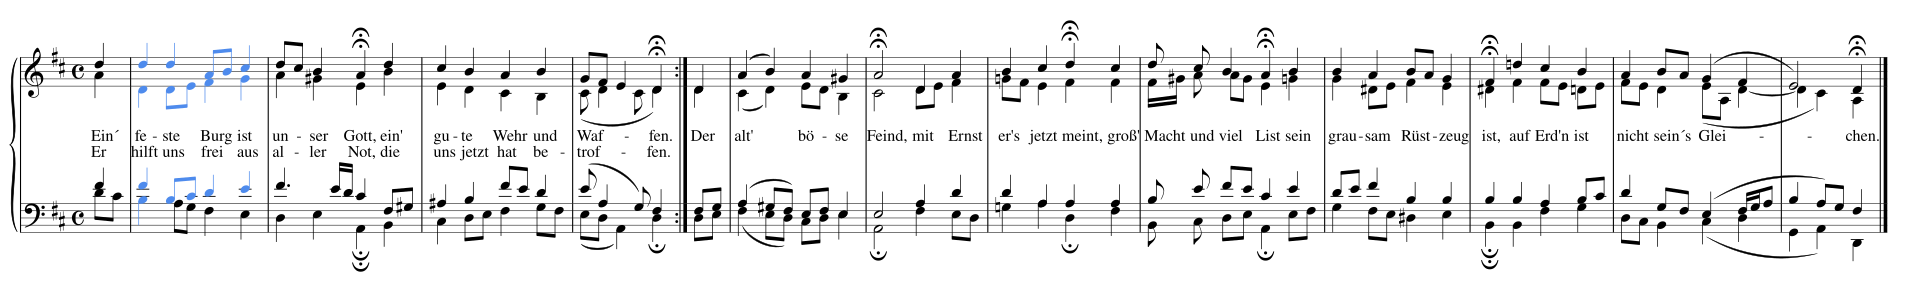

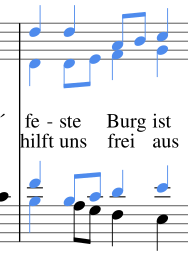

Highlighted 16 notes from the binary window.


In [15]:
# Reuses window_xml_ids from the piano-roll highlight cell above.
if mei_path is None or not window_xml_ids:
    print("Skipped. Need a resolved MEI path and xml:id values from the window cell.")
    annotated_svgs = None
else:
    annots = [
        {
            "text": "Binary window",
            "type": "score",
            "plist": window_xml_ids,
            "xml_id": "binary-window-annot",
        }
    ]
    with vrv_quiet():
        vrv_set_options(
            pageWidth=12000,
            pageHeight=1200,
            scale=40,
            breaks="none",
            removeIds=False,
            xmlIdSeed=0,
        )
        vrv_load_from_file(str(mei_path))
        annotated_svgs = vrv_process_annotations(
            annots,
            highlight_color=WINDOW_FILL,
            highlight_style="mei-friend",
            shape_only=True,
            display=True,
            return_svgs=True,
        )
    excerpt_svgs = vrv_crop_svgs_to_ids(
        annotated_svgs,
        window_xml_ids,
        x_padding=400,
        y_padding=450,
        output_scale=1.25,
        include_staff_context=True,
    )
    for svg in excerpt_svgs:
        vrv_display_svg(svg)
    print(f"Highlighted {len(window_xml_ids)} notes from the binary window.")


## What was produced?

- `df_pitch` / `df_events` from one CMN MEI source (self-contained parse).
- `binary.matrix` + `binary.meta` with provenance (`BinaryMatrixBundle`).
- A inspected slice of the raw 0/1 grid.
- `reconstructed_df` and its piano roll (grid → notes).
- The same binary window highlighted on the original `df_pitch` piano roll.
- MEI highlights for that window via `xml:id` provenance.

**Next:** convolution intuition in [`binary_convolution_explained.ipynb`](binary_convolution_explained.ipynb),
then motif / chord / texture search in [`binary_pattern_search.ipynb`](binary_pattern_search.ipynb). Guide:
[Analyse representations](../docs/guides/analysis.md).

**Next:** convolution intuition in [`binary_convolution_explained.ipynb`](binary_convolution_explained.ipynb),
then motif / chord / texture search in [`binary_pattern_search.ipynb`](binary_pattern_search.ipynb). Guide:
[Analyse representations](../docs/guides/analysis.md).
